<a href="https://colab.research.google.com/github/Makkonenexe/CI345_Machine_Learning/blob/main/%20Lab10%26lab11%20-%20Decision%20Tree%20and%20svm%20for%20Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab10&lab11 - Decision Tree and svm for Weather



# Step1: Loading Data


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [5]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Mount Google Drive
weather_file = '/content/drive/MyDrive/CI345_ML/Data/Weather.csv'
weather_table = pd.read_csv(weather_file)
weather_table.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No


# Step2: Basic Data Analysis

In [6]:
df = weather_table.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Day         14 non-null     object
 1   Outlook     14 non-null     object
 2   Temp        14 non-null     object
 3   Humidity    14 non-null     object
 4   Wind        14 non-null     object
 5   PlayTennis  14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes


In [7]:
df.shape

(14, 6)

In [8]:
df.isnull().sum()

,0
Day,0
Outlook,0
Temp,0
Humidity,0
Wind,0
PlayTennis,0


# Step3: Data Visualization

<Axes: xlabel='PlayTennis'>

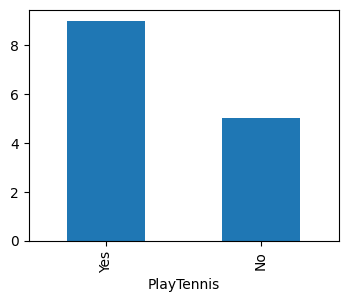

In [9]:
res = df.PlayTennis.value_counts()
res.plot(kind='bar', figsize = (4, 3))

# Step4: Processing data

In [10]:
# mehtod 1: Use LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Humidity'] = le.fit_transform(df['Humidity'])
df['Wind'] = le.fit_transform(df['Wind'])

df.head(1)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,0,1,No


In [11]:
print(df.Outlook.unique())
print(df.Temp.unique())

['Sunny' 'Overcast' 'Rain']
['Hot' 'Mild' 'Cool' 'Cold']


In [12]:
# mehtod 2: Use mapping method
df['Outlook'] = df['Outlook'].map({'Sunny': 0, 'Overcast': 1, 'Rain': 2})
df['Temp'] = df['Temp'].map({'Hot': 0, 'Mild': 1, 'Cool': 2})
df.head(14)

,Day,Outlook,Temp,Humidity,Wind,PlayTennis
0,D1,0,0.0,0,1,No
1,D2,0,0.0,0,0,No
2,D3,1,0.0,0,1,Yes
3,D4,2,1.0,0,1,Yes
4,D5,2,2.0,1,1,Yes
5,D6,2,2.0,1,0,No
6,D7,1,2.0,1,1,Yes
7,D8,0,1.0,0,1,No
8,D9,0,NaN,1,1,Yes
9,D10,2,1.0,1,0,Yes


# Step5: Get Data and target

In [13]:
data = df[['Outlook','Temp','Humidity','Wind']]
target = df['PlayTennis']
data.head(2)
target.head(2)


,PlayTennis
0,No
1,No


# Step6: Classification by DT

In [31]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (data, target, random_state = 13, test_size = 0.4)

# Remove rows with NaN values from data_train and target_train
nan_in_train = data_train.isna().any(axis=1)
data_train = data_train[~nan_in_train]
target_train = target_train[~nan_in_train]

# Remove rows with NaN values from data_test and target_test
nan_in_test = data_test.isna().any(axis=1)
data_test = data_test[~nan_in_test]
target_test = target_test[~nan_in_test]

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

(8, 4)
(5, 4)
(8,)
(5,)


In [32]:
# Step 4: Create a decision tree
from sklearn import tree
dt_classifier = tree.DecisionTreeClassifier(max_depth=4)

#Training the decision classifier
dt_classifier.fit (- data_train, y = target_train)
print(dt_classifier)

# Step 5: Testing
predicted = dt_classifier.predict(X= data_test)

# Step 6: Evaluation, Classification report
from sklearn.metrics import classification_report
report = classification_report (target_test, predicted)
print (report)



DecisionTreeClassifier(max_depth=4)
              precision    recall  f1-score   support

          No       0.40      1.00      0.57         2
         Yes       0.00      0.00      0.00         3

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
from sklearn.metrics import classification_report
report = classification_report (target_test, predicted)
print (report)
# use confusion matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------confusion matrix')
print(matrix)

              precision    recall  f1-score   support

          No       0.33      1.00      0.50         2
         Yes       0.00      0.00      0.00         4

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6

------confusion matrix
[[2 0]
 [4 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Lab11- Use SVM


In [25]:
# Show training and testing data
# what is the output
print(data_train[:3])
print(data_test[:3])

print(target_train[:3])
print(target_test[:3])
#

    Outlook  Temp  Humidity  Wind
1         0   0.0         0     0
4         2   2.0         1     1
13        2   1.0         0     0
    Outlook  Temp  Humidity  Wind
9         2   1.0         1     0
11        1   1.0         0     0
5         2   2.0         1     0
1      No
4     Yes
13     No
Name: PlayTennis, dtype: object
9     Yes
11    Yes
5      No
Name: PlayTennis, dtype: object


In [37]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Create svm calssifier
svm_classifier = SVC(kernel= 'sigmoid')

# use training dataset
svm_classifier.fit(X= data_train, y= target_train)

# use testing dataset to test the classifier
predicted = svm_classifier.predict(X= data_test)

# print the confusion matrix and score report
report = classification_report (target_test, predicted)
print (report)

# use confusion matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------confusion matrix')
print(matrix)
print('-----')
print(predicted)
actual = target_test
print(actual)


              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5

------confusion matrix
[[0 2]
 [0 3]]
-----
['Yes' 'Yes' 'Yes' 'Yes' 'Yes']
9     Yes
11    Yes
5      No
3     Yes
7      No
Name: PlayTennis, dtype: object


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Use KNN


# Use K numbers

In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

for k in range(1,9, 2):
  print(f'\n--- Applying KNN with k = {k} ---')
  # Create KNN classifier
  knn_classifier = KNeighborsClassifier(n_neighbors= k)
  # Train the classifier
  knn_classifier.fit(X= data_train, y= target_train)
  # Make preidctions on the test set
  predicted = knn_classifier.predict(X= data_test)
  # Print the confusion matrix and score report
  report = classification_report (target_test, predicted)
  print (report)


--- Applying KNN with k = 1 ---
              precision    recall  f1-score   support

          No       0.25      0.50      0.33         2
         Yes       0.00      0.00      0.00         3

    accuracy                           0.20         5
   macro avg       0.12      0.25      0.17         5
weighted avg       0.10      0.20      0.13         5


--- Applying KNN with k = 3 ---
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5


--- Applying KNN with k = 5 ---
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m